# 预训练语义分割模型预测-单张图像-Python API

## Goal of Use Python API:提取底层数据，将模型嵌入到自己的项目中

## 1.进入 mmsegmentation 主目录

In [1]:
import os

work_dir = '/root/LearningMMSegmentation/mmsegmentation'
if os.getcwd() != work_dir:
    os.chdir(work_dir)
    
print(f"当前工作目录: {os.getcwd()}")

当前工作目录: /root/LearningMMSegmentation/mmsegmentation


## 2.导入工具包

In [2]:
# 检查依赖包是否能正常导入
import torch
import mmcv
import mmseg
from mmengine import Config
print(f"PyTorch 版本: {torch.__version__}")
print(f"MMSegmentation 版本: {mmseg.__version__}")

PyTorch 版本: 1.10.1+cu113
MMSegmentation 版本: 1.1.1


## 3.载入模型

In [3]:
# 模型 config 配置文件
config_file = 'configs/segformer/segformer_mit-b5_8xb2-160k_ade20k-640x640.py'
checkpoint_file = 'https://download.openmmlab.com/mmsegmentation/v0.5/segformer/segformer_mit-b5_640x640_160k_ade20k/segformer_mit-b5_640x640_160k_ade20k_20210801_121243-41d2845b.pth'
# 检查配置文件是否存在
if not os.path.exists(config_file):
    print(f"错误：找不到配置文件 {config_file}，请检查是否完整解压了 MMSegmentation")

## 4.初始化模型

In [4]:
from mmseg.apis import init_model

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# 重点突出：v1.x 的 init_model 逻辑与 v0.x 略有不同
model = init_model(config_file, checkpoint_file, device=device)
print("模型初始化成功！")

/root/LearningMMSegmentation/mmsegmentation/mmseg/models/builder.py:36: UserWarning: ``build_loss`` would be deprecated soon, please use ``mmseg.registry.MODELS.build()`` 
  warnings.warn('``build_loss`` would be deprecated soon, please use '
/root/LearningMMSegmentation/mmsegmentation/mmseg/models/losses/cross_entropy_loss.py:236: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  'Default ``avg_non_ignore`` is False, if you would like to '


Loads checkpoint by http backend from path: https://download.openmmlab.com/mmsegmentation/v0.5/segformer/segformer_mit-b5_640x640_160k_ade20k/segformer_mit-b5_640x640_160k_ade20k_20210801_121243-41d2845b.pth
模型初始化成功！


## 5.载入测试图像

In [5]:
import cv2

In [7]:
img_path = 'data/street_uk.jpeg'

In [8]:
img_bgr = cv2.imread(img_path)

In [9]:
img_bgr.shape

(1500, 2250, 3)

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

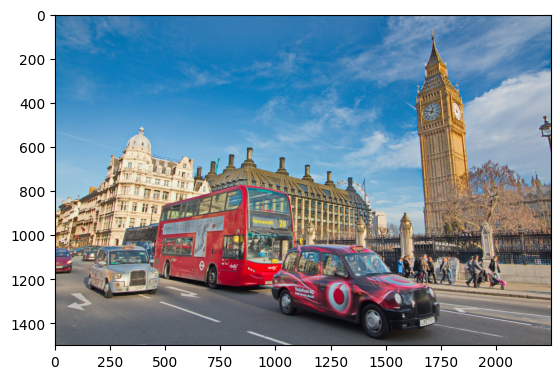

In [12]:
plt.imshow(img_bgr[:,:,::-1])
plt.show()

## 6.语义分割推理预测

In [14]:
# 导入模型推理专属的函数
from mmseg.apis import inference_model

In [15]:
result = inference_model(model, img_bgr)

In [16]:
# result

<SegDataSample(

    META INFORMATION
    scale_factor: (0.4266666666666667, 0.4266666666666667)
    ori_shape: (1500, 2250)
    img_path: None
    img_shape: (640, 960)

    DATA FIELDS
    seg_logits: <PixelData(
        
            META INFORMATION
        
            DATA FIELDS
            data: tensor([[[-10.9640, -10.9640, -10.9640,  ...,  -8.0148,  -8.0148,  -8.0148],
                         [-10.9640, -10.9640, -10.9640,  ...,  -8.0148,  -8.0148,  -8.0148],
                         [-10.9640, -10.9640, -10.9640,  ...,  -8.0148,  -8.0148,  -8.0148],
                         ...,
                         [-10.3036, -10.3036, -10.3036,  ..., -15.0315, -15.0315, -15.0315],
                         [-10.3036, -10.3036, -10.3036,  ..., -15.0315, -15.0315, -15.0315],
                         [-10.3036, -10.3036, -10.3036,  ..., -15.0315, -15.0315, -15.0315]],
                
                        [[ -7.9453,  -7.9453,  -7.9453,  ...,  -9.4230,  -9.4230,  -9.4230],
             

In [17]:
result.keys()

['seg_logits', 'pred_sem_seg']

## 6.1语义分割预测结果-定性类别('pred_sem_seg')

In [18]:
# 类别：0-18，共 19 个 类别
result.pred_sem_seg.data.shape

torch.Size([1, 1500, 2250])

In [20]:
import numpy as np

In [21]:
np.unique(result.pred_sem_seg.data.cpu())

array([  0,   1,   2,   4,   6,  11,  12,  20,  38,  80,  84,  87, 148])

In [22]:
result.pred_sem_seg.data.shape

torch.Size([1, 1500, 2250])

In [23]:
result.pred_sem_seg.data

tensor([[[2, 2, 2,  ..., 2, 2, 2],
         [2, 2, 2,  ..., 2, 2, 2],
         [2, 2, 2,  ..., 2, 2, 2],
         ...,
         [6, 6, 6,  ..., 6, 6, 6],
         [6, 6, 6,  ..., 6, 6, 6],
         [6, 6, 6,  ..., 6, 6, 6]]], device='cuda:0')

In [24]:
pred_mask = result.pred_sem_seg.data[0].detach().cpu().numpy()

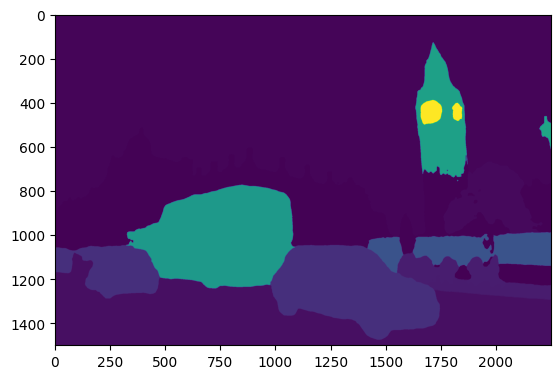

In [25]:
plt.imshow(pred_mask)
plt.show()

## 6.2语义分割预测结果-定量置信度('seg_logits')

In [26]:
# 置信度
result.seg_logits.data.shape

torch.Size([150, 1500, 2250])

## 7.可视化语义分割预测结果

### 7.1可视化语义分割预测结果-方法一

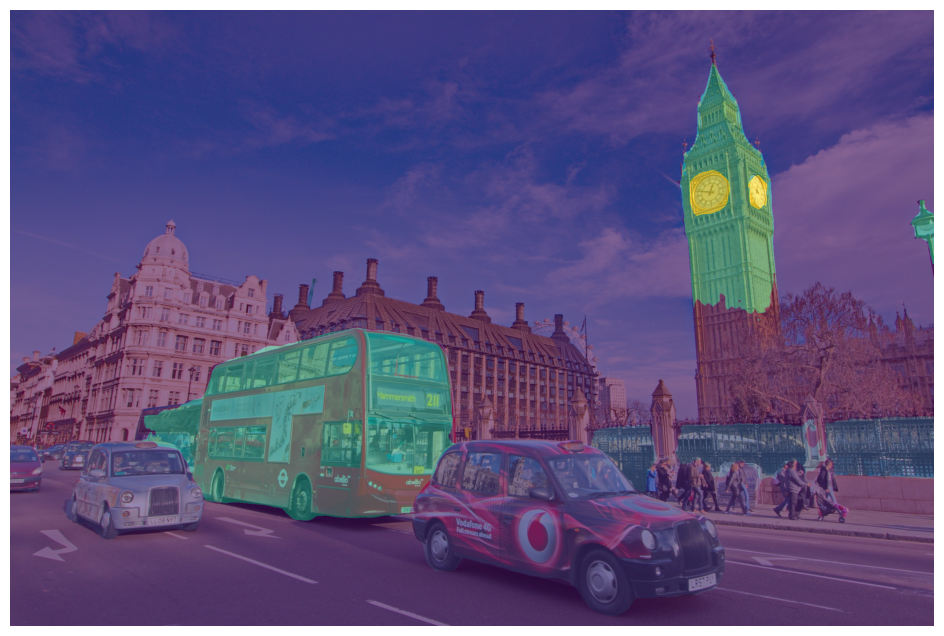

In [27]:
plt.figure(figsize=(14, 8))
plt.imshow(img_bgr[:,:,::-1])
plt.imshow(pred_mask, alpha=0.55) # !!! alpha 高亮区域透明度，越小越接近原图 !!!
plt.axis('off')
plt.savefig('outputs/B2-1.jpg')
plt.show()

### 7.2可视化语义分割预测结果-方法二（和原图并排显示）

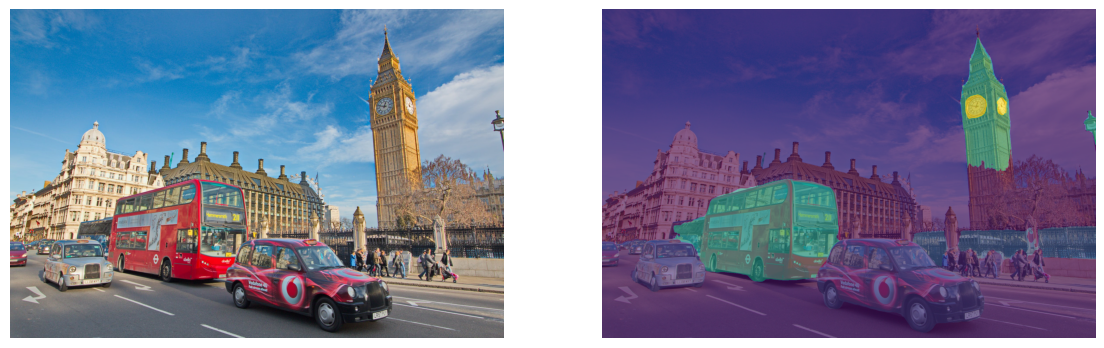

In [28]:
plt.figure(figsize=(14, 8))

plt.subplot(1,2,1)
plt.imshow(img_bgr[:,:,::-1])
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_bgr[:,:,::-1])
plt.imshow(pred_mask, alpha=0.6) # alpha 高亮区域透明度，越小越接近原图
plt.axis('off')
plt.savefig('outputs/B2-2.jpg')
plt.show()

### 7.3可视化语义分割预测结果-方法三

按照`mmseg/datasets/cityscapes.py`定义的配色方案

In [29]:
from mmseg.apis import show_result_pyplot

In [30]:
img_viz = show_result_pyplot(model, img_path, result, opacity=0.8, title='MMSeg', out_file='outputs/B2-3.jpg')

/root/miniconda3/envs/mmseg_env/lib/python3.7/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


opacity控制透明度，越小，越接近原图。

In [31]:
img_viz.shape

(1500, 2250, 3)

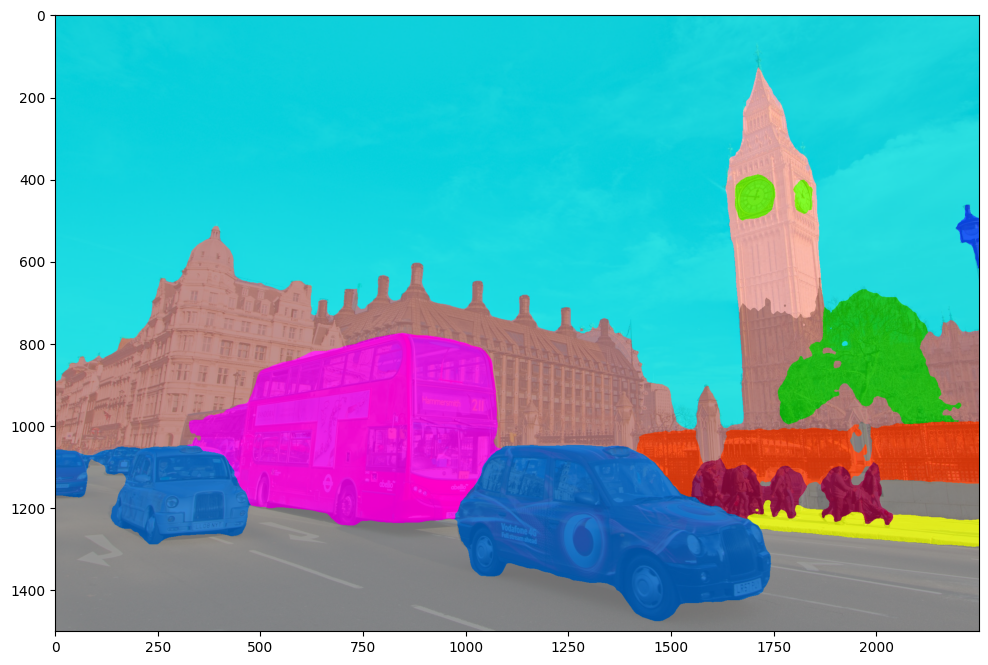

In [32]:
plt.figure(figsize=(14, 8))
plt.imshow(img_viz)
plt.show()

### 7.4可视化语义分割预测结果-方法四（加图例）

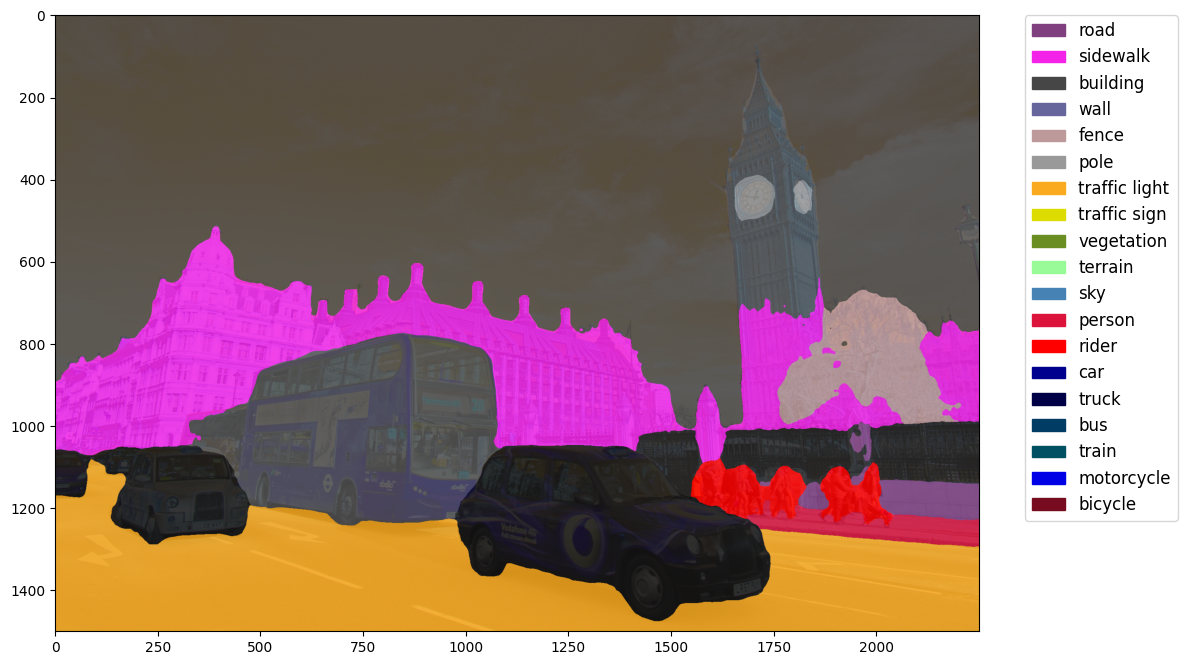

In [33]:
from mmseg.datasets import cityscapes
import numpy as np
import mmcv 
from PIL import Image

# 获取类别名和调色板
classes = cityscapes.CityscapesDataset.METAINFO['classes']
palette = cityscapes.CityscapesDataset.METAINFO['palette']
opacity = 0.15 # 透明度，越大越接近原图

# 将分割图按调色板染色
# seg_map = result[0].astype('uint8')
seg_map = pred_mask.astype('uint8')
seg_img = Image.fromarray(seg_map).convert('P')
seg_img.putpalette(np.array(palette, dtype=np.uint8))

from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
plt.figure(figsize=(14, 8))
im = plt.imshow(((np.array(seg_img.convert('RGB')))*(1-opacity) + mmcv.imread(img_path)*opacity) / 255)

# 为每一种颜色创建一个图例
patches = [mpatches.Patch(color=np.array(palette[i])/255., label=classes[i]) for i in range(len(classes))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize='large')

plt.savefig('outputs/B2-4.jpg')
plt.show()